Shape: (374, 13)

Columns:
 ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data Types:
 Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing Values:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category    

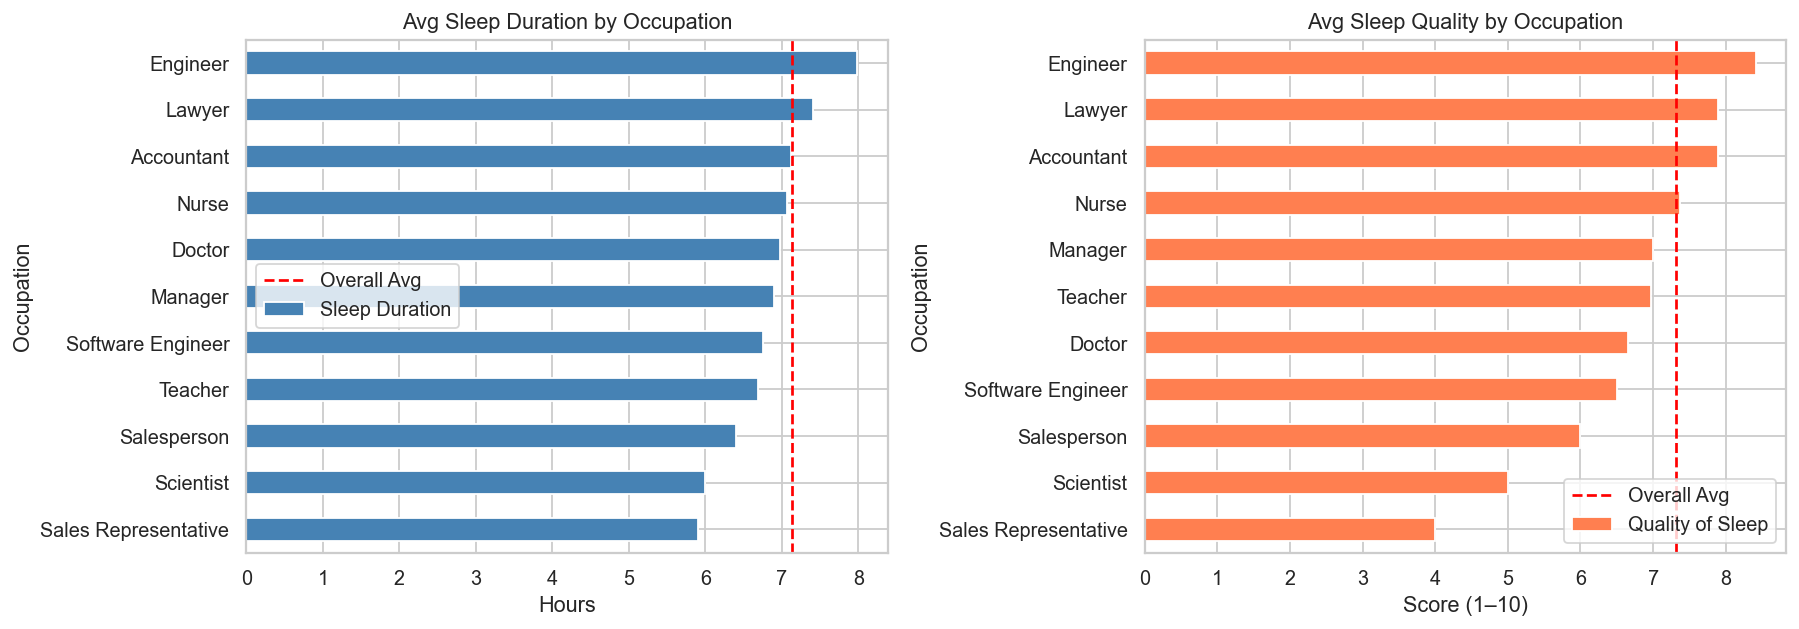

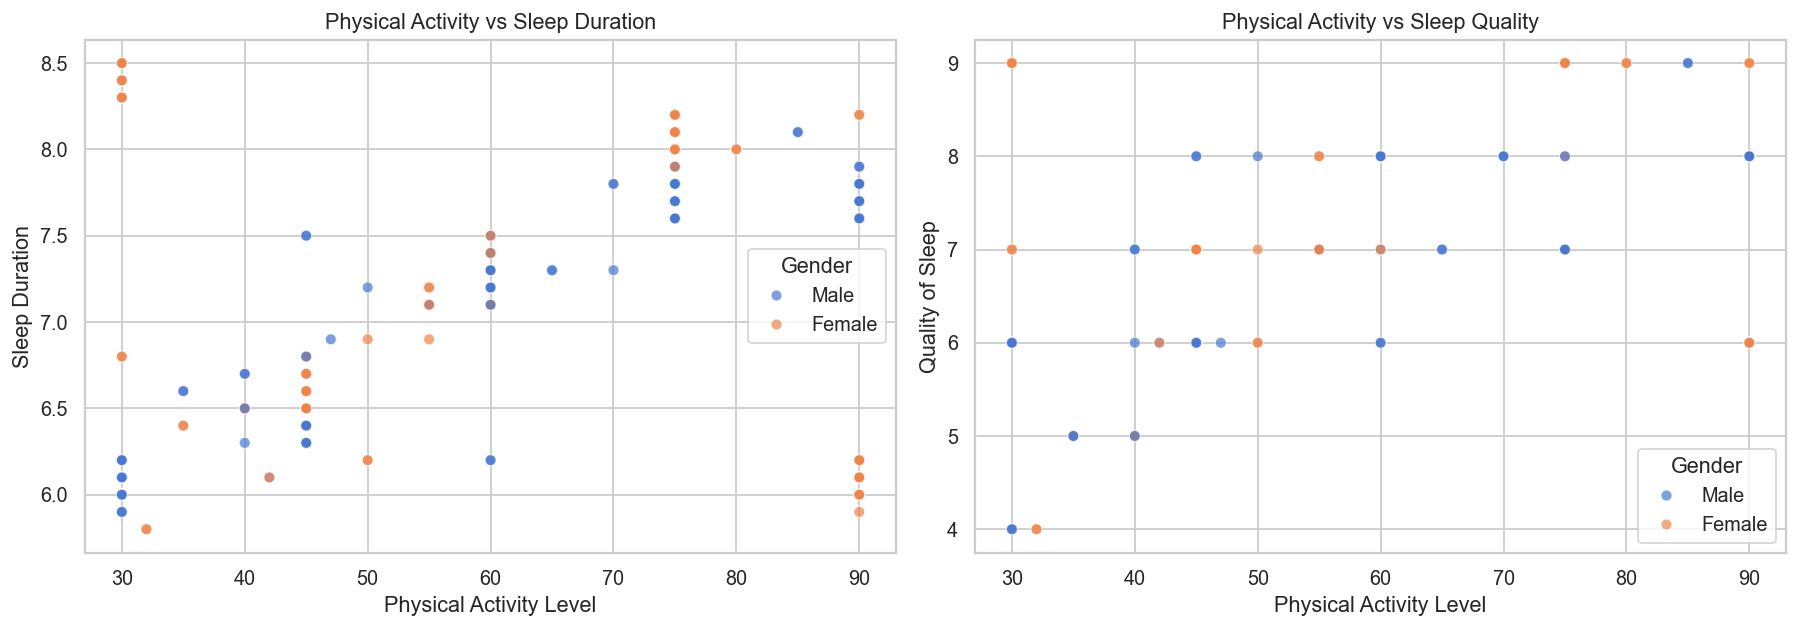


 Correlation — Activity vs Duration: r=0.21 (p=0.000)
 Correlation — Activity vs Quality:  r=0.19 (p=0.000)


/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Stress Level", y="Sleep Duration", ax=axes[0], palette="Blues")
/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Stress Level", y="Quality of Sleep", ax=axes[1], palette="Reds")


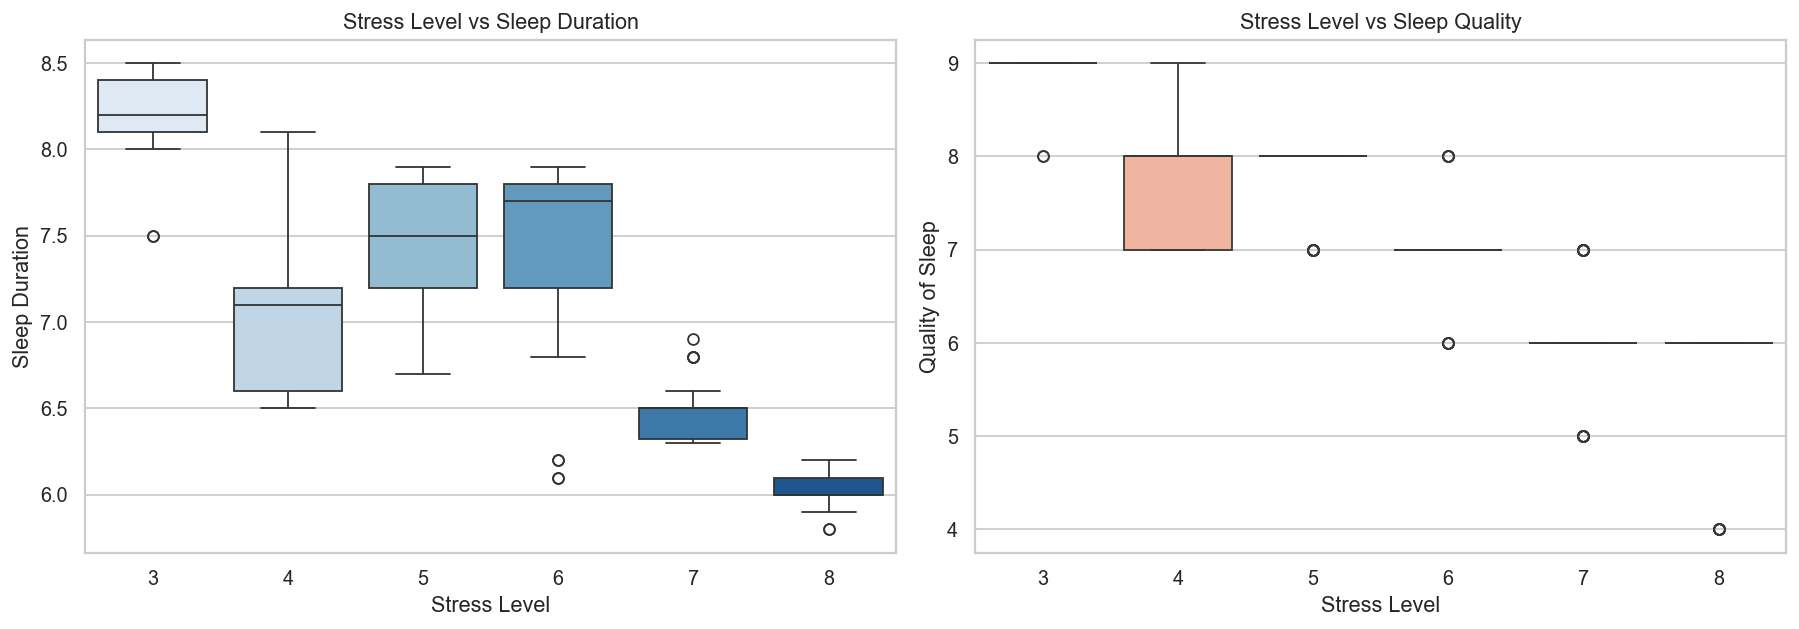


 Correlation — Stress vs Sleep Duration: r=-0.81 (p=0.000)


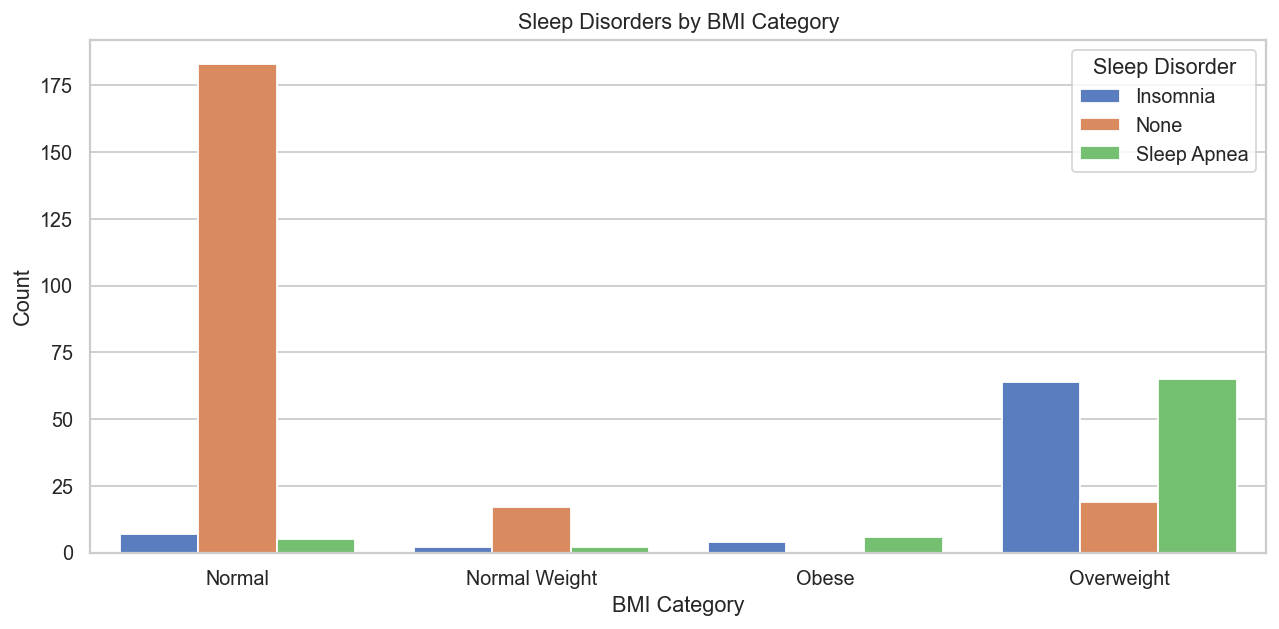


 BMI vs Sleep Disorder distribution:
Sleep Disorder  Insomnia  None  Sleep Apnea  All
BMI Category                                    
Normal                 7   183            5  195
Normal Weight          2    17            2   21
Obese                  4     0            6   10
Overweight            64    19           65  148
All                   77   219           78  374

 Gender-wise averages:
         Sleep Duration  Quality of Sleep  Stress Level  \
Gender                                                   
Female        7.229730          7.664865      4.675676   
Male          7.036508          6.968254      6.079365   

        Physical Activity Level  
Gender                           
Female                59.140541  
Male                  59.201058  


/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Gender", y="Sleep Duration", palette="pastel", ax=axes[0])
/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Gender", y="Quality of Sleep", palette="pastel", ax=axes[1])


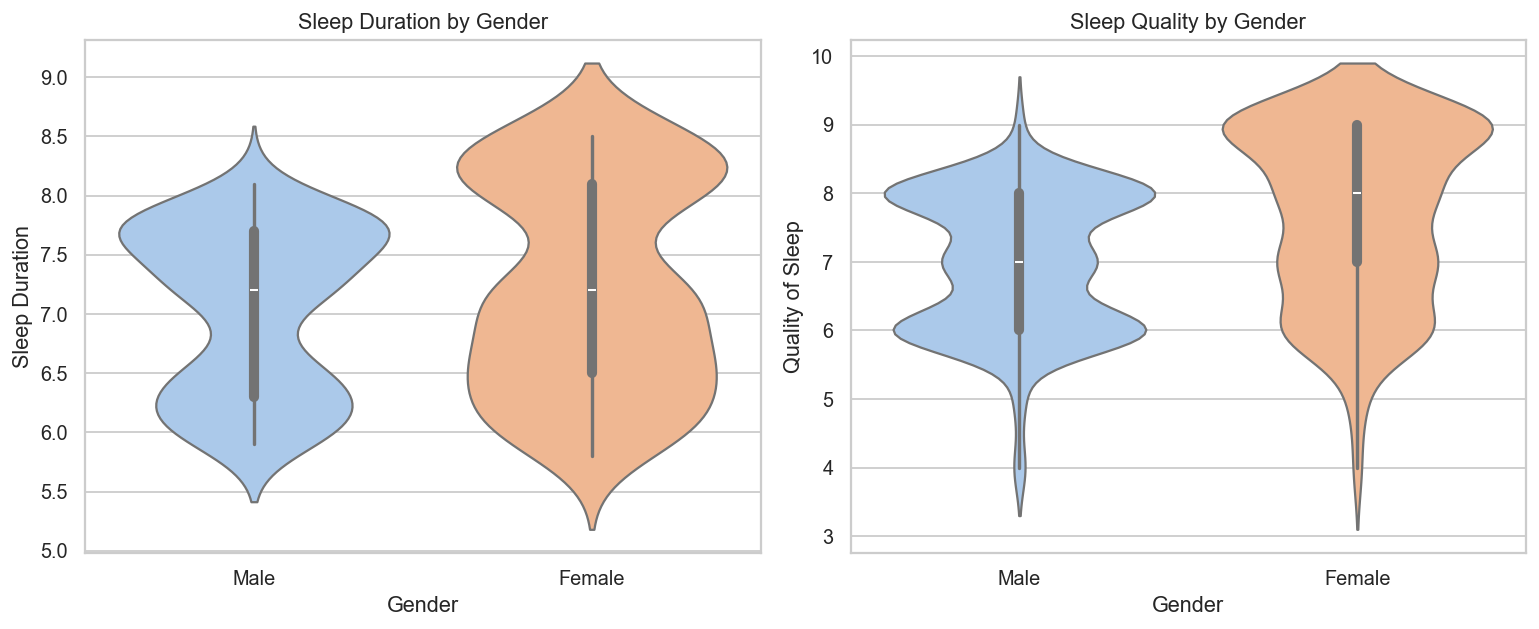

/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sleep Disorder", y="Systolic", palette="Set2", ax=axes[0])
/var/folders/m6/vr0p24f167b9lm5f99_dw0_r0000gn/T/ipykernel_3519/1424964156.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sleep Disorder", y="Heart Rate", palette="Set2", ax=axes[1])


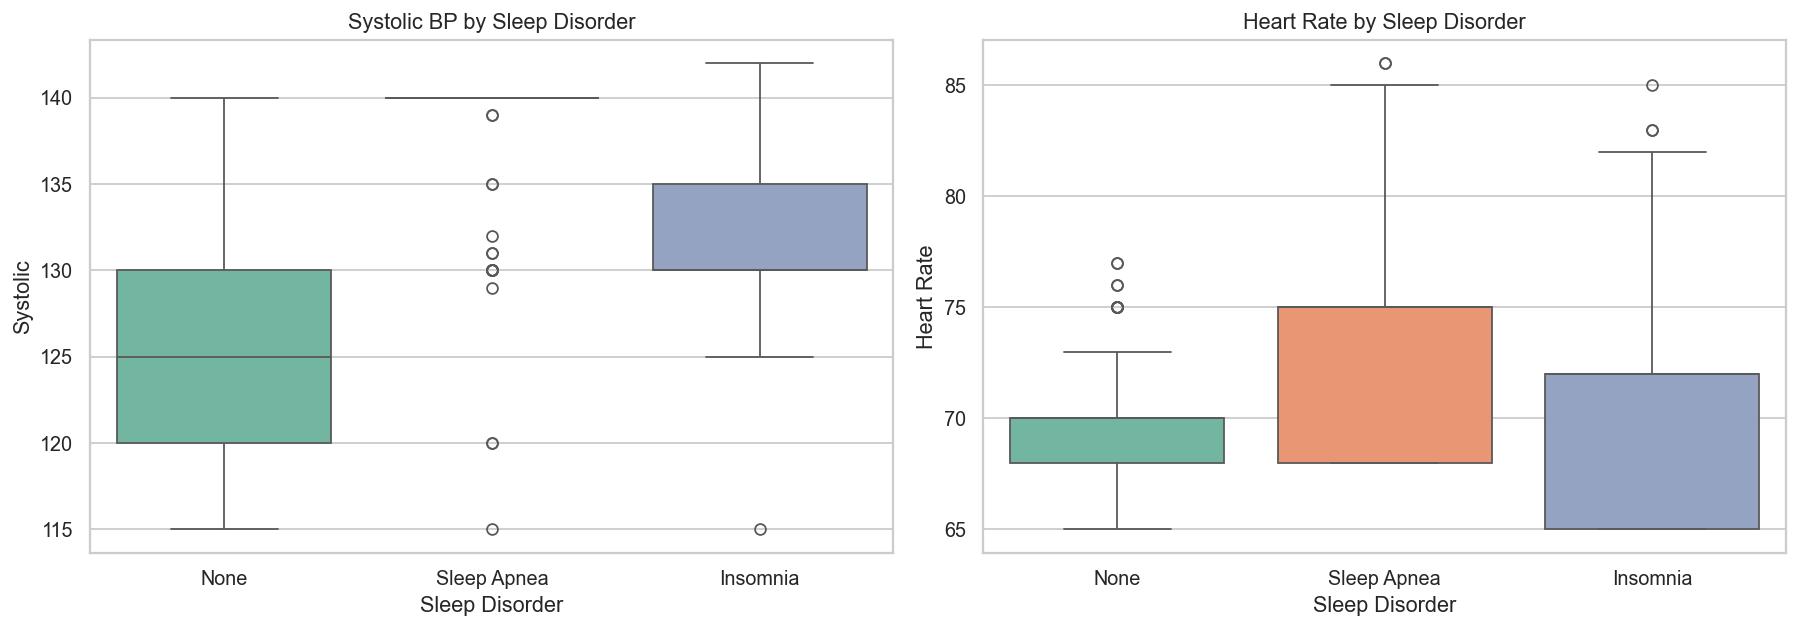


 BP and Heart Rate differences across sleep disorder groups plotted.


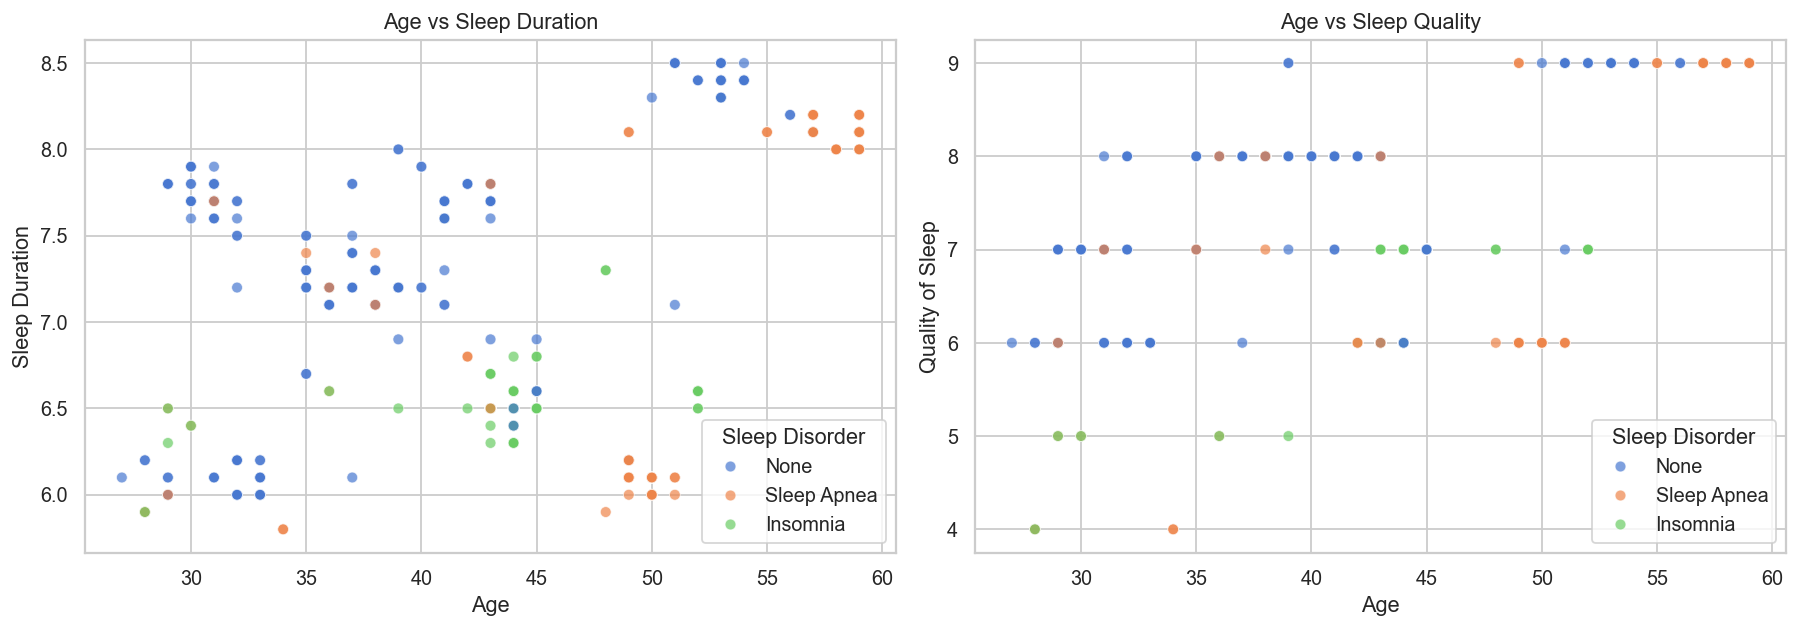


 Correlation — Age vs Sleep Quality: r=0.47 (p=0.000)


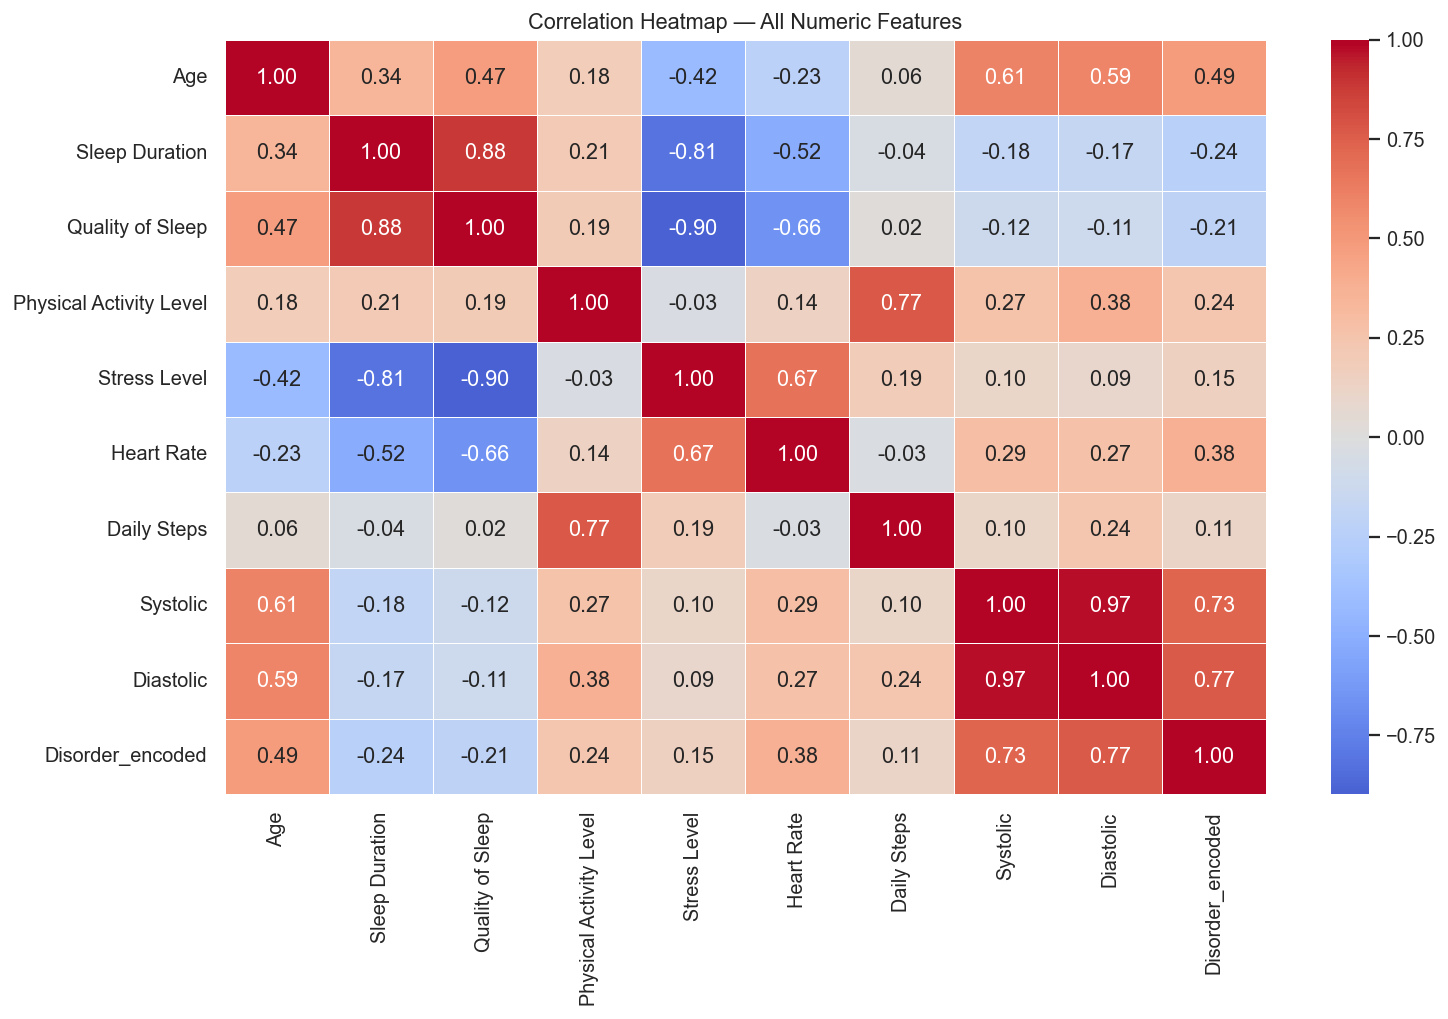

SUMMARY INSIGHTS
• Most sleep-deprived occupation: Sales Representative
• Best sleeping occupation: Engineer
• Physical activity correlates with sleep quality: r=0.19
• Stress negatively correlates with sleep: r=-0.81
• Age correlation with sleep quality: r=0.47
• Sleep disorder prevalence:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [3]:
# Sleep Health & Lifestyle — Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# LOAD & INSPECT
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

# Clean 
# Fill missing Sleep Disorder with 'None'
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Split Blood Pressure into systolic / diastolic
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)

print("\nCleaned shape:", df.shape)

# WHICH OCCUPATIONS SLEEP THE LEAST / WORST QUALITY?
occ = (
    df.groupby("Occupation")[["Sleep Duration", "Quality of Sleep"]]
    .mean()
    .sort_values("Sleep Duration")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

occ["Sleep Duration"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Avg Sleep Duration by Occupation")
axes[0].set_xlabel("Hours")
axes[0].axvline(df["Sleep Duration"].mean(), color="red", linestyle="--", label="Overall Avg")
axes[0].legend()

occ["Quality of Sleep"].sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Avg Sleep Quality by Occupation")
axes[1].set_xlabel("Score (1–10)")
axes[1].axvline(df["Quality of Sleep"].mean(), color="red", linestyle="--", label="Overall Avg")
axes[1].legend()

plt.tight_layout()
plt.savefig("q1_occupation_sleep.png")
plt.show()

# DOES PHYSICAL ACTIVITY LEAD TO BETTER SLEEP?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Physical Activity Level", y="Sleep Duration",
                hue="Gender", alpha=0.7, ax=axes[0])
axes[0].set_title("Physical Activity vs Sleep Duration")

sns.scatterplot(data=df, x="Physical Activity Level", y="Quality of Sleep",
                hue="Gender", alpha=0.7, ax=axes[1])
axes[1].set_title("Physical Activity vs Sleep Quality")

plt.tight_layout()
plt.savefig("q2_physical_activity_sleep.png")
plt.show()

corr_dur, p1 = stats.pearsonr(df["Physical Activity Level"], df["Sleep Duration"])
corr_qual, p2 = stats.pearsonr(df["Physical Activity Level"], df["Quality of Sleep"])
print(f"\n Correlation — Activity vs Duration: r={corr_dur:.2f} (p={p1:.3f})")
print(f" Correlation — Activity vs Quality:  r={corr_qual:.2f} (p={p2:.3f})")

# STRESS LEVEL vs SLEEP DURATION & QUALITY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Stress Level", y="Sleep Duration", ax=axes[0], palette="Blues")
axes[0].set_title("Stress Level vs Sleep Duration")

sns.boxplot(data=df, x="Stress Level", y="Quality of Sleep", ax=axes[1], palette="Reds")
axes[1].set_title("Stress Level vs Sleep Quality")

plt.tight_layout()
plt.savefig("q3_stress_sleep.png")
plt.show()

corr_s, p3 = stats.pearsonr(df["Stress Level"], df["Sleep Duration"])
print(f"\n Correlation — Stress vs Sleep Duration: r={corr_s:.2f} (p={p3:.3f})")

# BMI CATEGORY & SLEEP DISORDERS
bmi_disorder = (
    df.groupby(["BMI Category", "Sleep Disorder"])
    .size()
    .reset_index(name="Count")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=bmi_disorder, x="BMI Category", y="Count", hue="Sleep Disorder", ax=ax)
ax.set_title("Sleep Disorders by BMI Category")
plt.tight_layout()
plt.savefig("q4_bmi_disorder.png")
plt.show()

print("\n BMI vs Sleep Disorder distribution:")
print(pd.crosstab(df["BMI Category"], df["Sleep Disorder"], margins=True))

# GENDER DIFFERENCES IN SLEEP PATTERNS
gender_stats = df.groupby("Gender")[["Sleep Duration", "Quality of Sleep",
                                      "Stress Level", "Physical Activity Level"]].mean()
print("\n Gender-wise averages:\n", gender_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df, x="Gender", y="Sleep Duration", palette="pastel", ax=axes[0])
axes[0].set_title("Sleep Duration by Gender")

sns.violinplot(data=df, x="Gender", y="Quality of Sleep", palette="pastel", ax=axes[1])
axes[1].set_title("Sleep Quality by Gender")

plt.tight_layout()
plt.savefig("q5_gender_sleep.png")
plt.show()

# BLOOD PRESSURE / HEART RATE vs SLEEP DISORDERS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Sleep Disorder", y="Systolic", palette="Set2", ax=axes[0])
axes[0].set_title("Systolic BP by Sleep Disorder")

sns.boxplot(data=df, x="Sleep Disorder", y="Heart Rate", palette="Set2", ax=axes[1])
axes[1].set_title("Heart Rate by Sleep Disorder")

plt.tight_layout()
plt.savefig("q6_bp_heartrate_disorder.png")
plt.show()
print("\n BP and Heart Rate differences across sleep disorder groups plotted.")

# AGE vs SLEEP QUALITY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Age", y="Sleep Duration", hue="Sleep Disorder", alpha=0.7, ax=axes[0])
axes[0].set_title("Age vs Sleep Duration")

sns.scatterplot(data=df, x="Age", y="Quality of Sleep", hue="Sleep Disorder", alpha=0.7, ax=axes[1])
axes[1].set_title("Age vs Sleep Quality")

plt.tight_layout()
plt.savefig("q7_age_sleep.png")
plt.show()

corr_age, p4 = stats.pearsonr(df["Age"], df["Quality of Sleep"])
print(f"\n Correlation — Age vs Sleep Quality: r={corr_age:.2f} (p={p4:.3f})")

# WHAT FACTORS PREDICT SLEEP DISORDERS? (Heatmap)
# Encode sleep disorder for correlation
df["Disorder_encoded"] = df["Sleep Disorder"].map({"None": 0, "Insomnia": 1, "Sleep Apnea": 2})

numeric_cols = ["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level",
                "Stress Level", "Heart Rate", "Daily Steps", "Systolic", "Diastolic", "Disorder_encoded"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — All Numeric Features")
plt.tight_layout()
plt.savefig("q8_correlation_heatmap.png")
plt.show()

# SUMMARY INSIGHTS
print("SUMMARY INSIGHTS")
print(f"• Most sleep-deprived occupation: {occ['Sleep Duration'].idxmin()}")
print(f"• Best sleeping occupation: {occ['Sleep Duration'].idxmax()}")
print(f"• Physical activity correlates with sleep quality: r={corr_qual:.2f}")
print(f"• Stress negatively correlates with sleep: r={corr_s:.2f}")
print(f"• Age correlation with sleep quality: r={corr_age:.2f}")
print(f"• Sleep disorder prevalence:\n{df['Sleep Disorder'].value_counts()}")